In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/Diabetes.csv')

**Data Overview**

In [31]:
# using head() function to show 5 data of dataset
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [32]:
# shows the data of bottom dataframe
df.tail(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [33]:
# returns the column label of the dataframe
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


df.info() functions shows the description of data types of the column, and non-null values.In this dataset, there contains 9 columns which stores integer and float values.

In [35]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


.describe() function is used to find the computation part like mean, standard deviation, lower and upper bound Q1,Q2,Q3 of the dataset.

In [36]:
#shows the total number of rows and column in a tuple
df.shape


(768, 9)

In [37]:
# shows the data types of each column
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [38]:
df.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


In [39]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


df.isnull().sum() function is used to find the null values of a dataset and sum is used to add the boolean true values is data is missing.

**Data Imputations**

In [40]:
df.mean()

,0
Pregnancies,3.845052
Glucose,120.894531
BloodPressure,69.105469
SkinThickness,20.536458
Insulin,79.799479
BMI,31.992578
DiabetesPedigreeFunction,0.471876
Age,33.240885
Outcome,0.348958


In [41]:
df.std()

,0
Pregnancies,3.369578
Glucose,31.972618
BloodPressure,19.355807
SkinThickness,15.952218
Insulin,115.244002
BMI,7.884160
DiabetesPedigreeFunction,0.331329
Age,11.760232
Outcome,0.476951


In [42]:
df.mode()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1.0,99,70.0,0.0,0.0,32.0,0.254,22.0,0.0
1,NaN,100,NaN,NaN,NaN,NaN,0.258,NaN,NaN


In [43]:
df.median()

,0
Pregnancies,3.0000
Glucose,117.0000
BloodPressure,72.0000
SkinThickness,23.0000
Insulin,30.5000
BMI,32.0000
DiabetesPedigreeFunction,0.3725
Age,29.0000
Outcome,0.0000


In [44]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


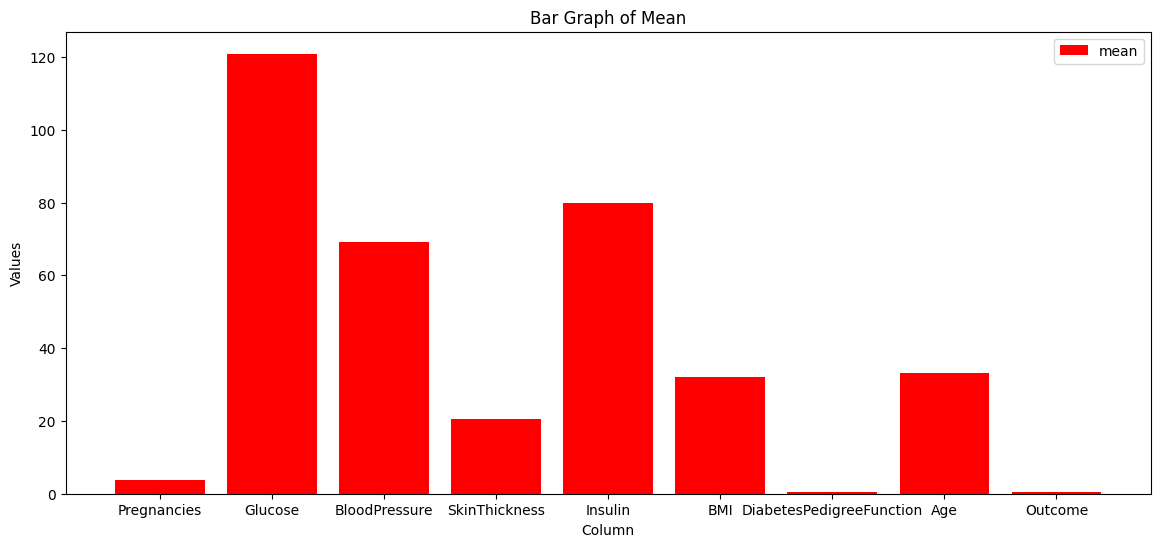

In [45]:
#Bar graph for mean
plt.figure(figsize = (14,6))
plt.bar(df.columns, df.mean(), color = 'red', label  = 'mean')

plt.xlabel('Column')
plt.ylabel('Values')
plt.title('Bar Graph of Mean')
plt.legend()
plt.show()


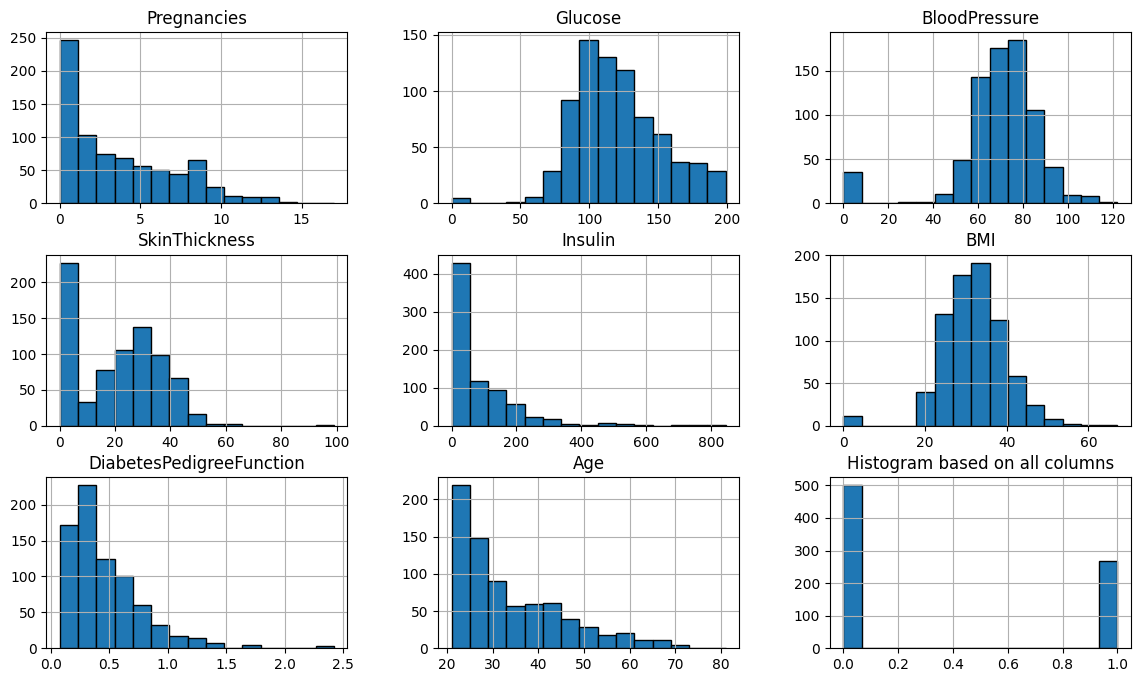

In [66]:
df.hist(bins = 15,figsize = (14,8), edgecolor = 'black')
plt.title('Histogram based on all columns')
plt.show()


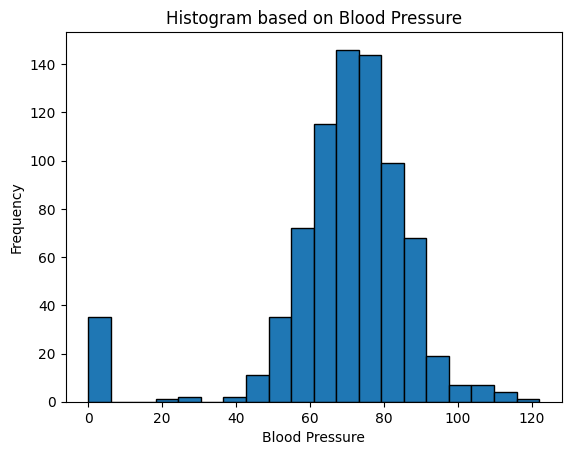

In [57]:
# histogram based on blood pressure
plt.hist(df['BloodPressure'], bins = 20, edgecolor = 'black')
plt.xlabel('Blood Pressure')
plt.ylabel('Frequency')
plt.title('Histogram based on Blood Pressure')
plt.show()

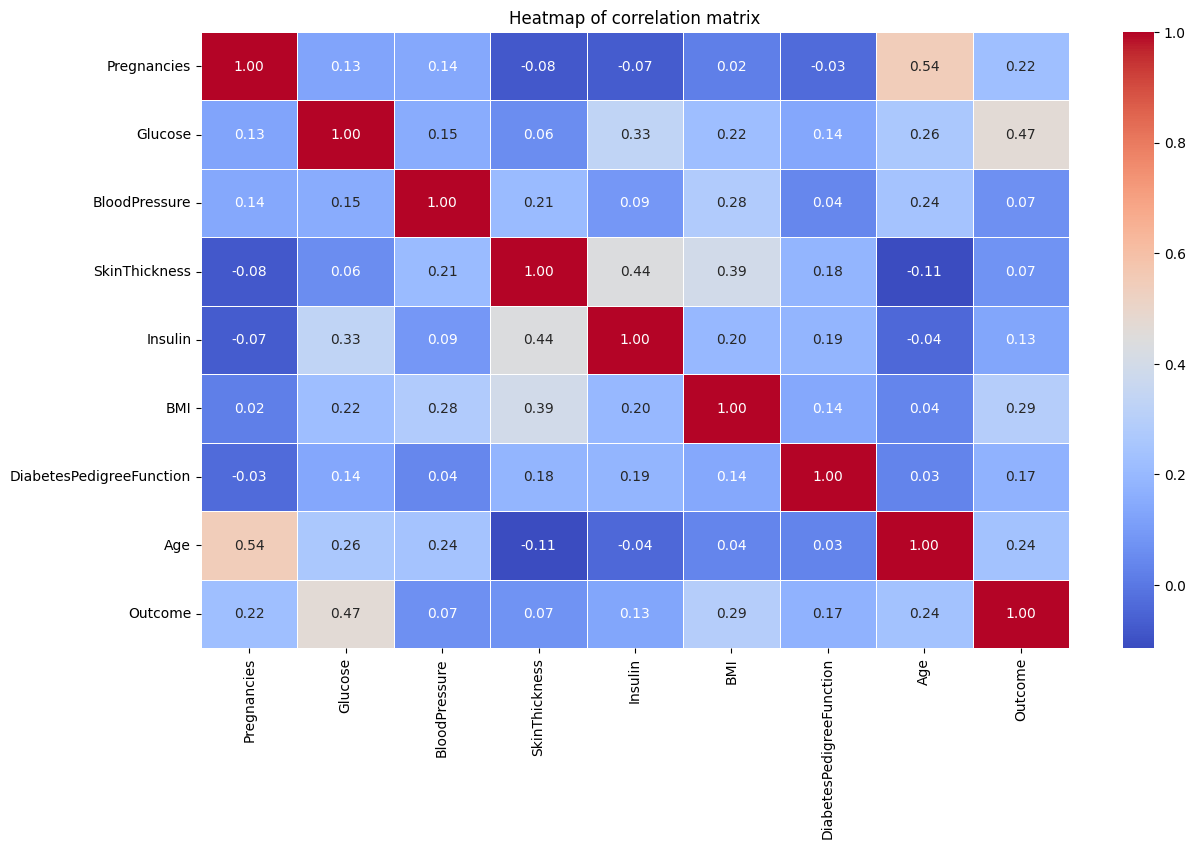

In [60]:
plt.figure(figsize = (14, 8))
sns.heatmap(df.corr(numeric_only = True),annot = True,fmt = ".2f", cmap = 'coolwarm', linewidths = 0.6)
plt.title('Heatmap of correlation matrix')
plt.show()

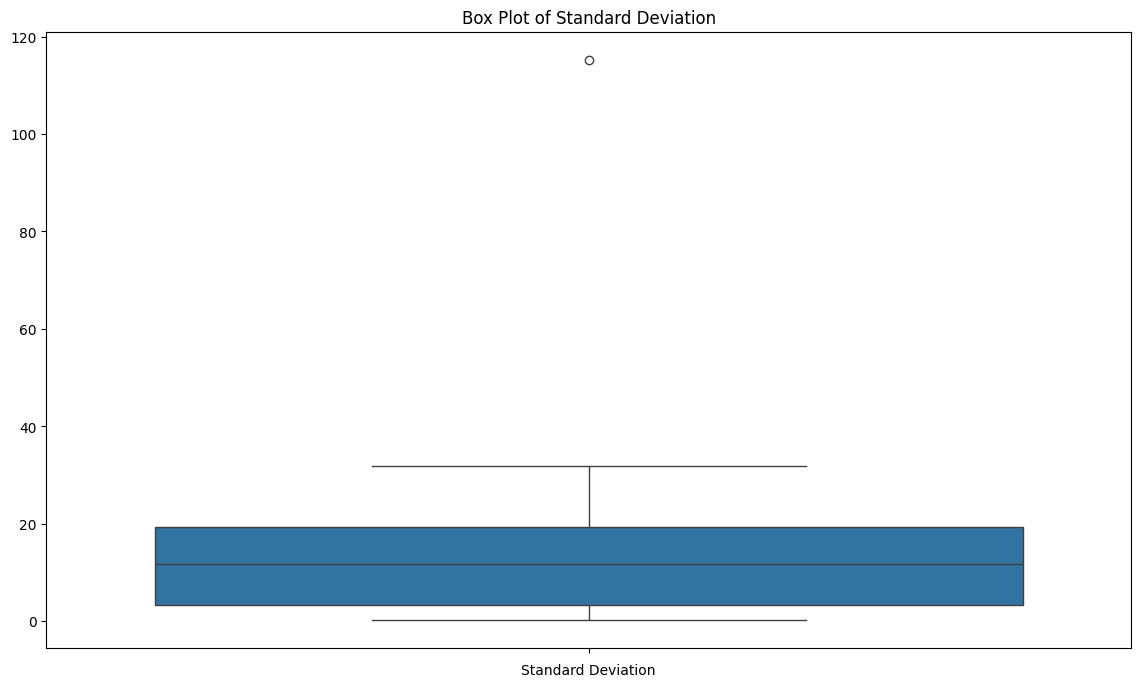

In [61]:
plt.figure(figsize = (14, 8))
sns.boxplot(df.std())
plt.xlabel('Standard Deviation')
plt.title("Box Plot of Standard Deviation")
plt.show()

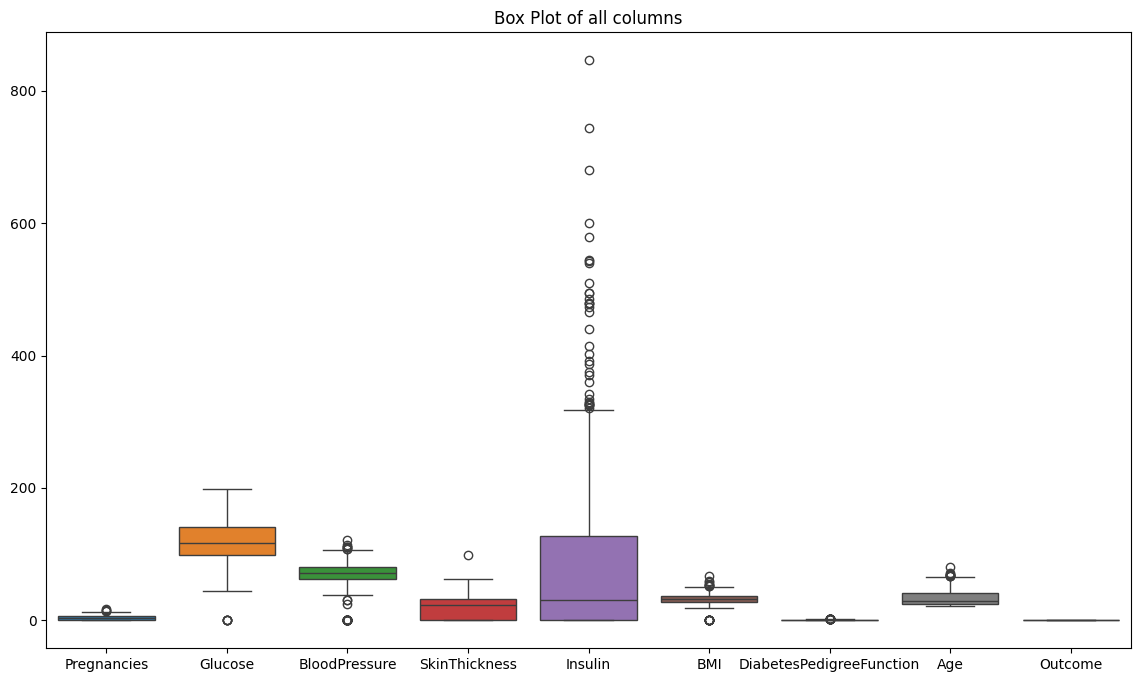

In [62]:
plt.figure(figsize = (14,8))
sns.boxplot(data = df)
plt.title('Box Plot of all columns')
plt.show()


**REGRESSION TASK**

**LINEAR REGRESSION**

**Separating features and target according to the requirement**

In [50]:

X = df.drop(columns = ['BloodPressure'])
#target variable
Y = df['BloodPressure']

In [51]:
X.columns

Index(['Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [52]:
Y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 768 entries, 0 to 767
Series name: BloodPressure
Non-Null Count  Dtype
--------------  -----
768 non-null    int64
dtypes: int64(1)
memory usage: 6.1 KB


In [53]:
X.shape


(768, 8)

In [54]:
Y.shape

(768,)

In [67]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.3, random_state = 42)


In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [75]:
model = LinearRegression()
model.fit(X_train_scaled, Y_train)

#making prediction
predictions = model.predict(X_test_scaled)
predictions

array([75.88044402, 70.0516516 , 61.85788874, 64.23760603, 75.43072846,
       82.56729661, 57.07928524, 71.38469441, 75.41049098, 83.3385876 ,
       71.17534608, 89.58304688, 66.8739444 , 73.06716023, 63.48573863,
       68.09433489, 71.74492996, 65.97964352, 68.58695069, 70.22021514,
       71.76836143, 68.223301  , 85.46401078, 65.839059  , 77.90577468,
       80.15255346, 67.00712707, 60.2653601 , 71.41535798, 68.83482892,
       82.10709792, 82.64249624, 75.13234121, 65.45881705, 79.46959363,
       72.79359035, 99.06415202, 70.21717028, 81.46860195, 67.47864505,
       65.35143115, 76.70130565, 84.20128426, 67.14130943, 59.19424624,
       68.56095771, 80.81237031, 72.73785182, 73.43544924, 89.39843178,
       62.37224431, 78.49534023, 85.42078117, 59.82105347, 60.429066  ,
       64.50569471, 81.43877555, 46.13897647, 71.22762759, 71.99580993,
       78.25015719, 72.4135738 , 71.73884628, 65.20747812, 68.45041863,
       79.9572384 , 63.9265562 , 75.83719284, 57.14635452, 73.70

In [73]:
mse = mean_squared_error(Y_test, predictions)
r2 = r2_score(Y_test, predictions)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 401.4765313200544
R^2 Score: 0.16648039688888183


**CLASSIFICATION TASK**

**LOGISTIC REGRESSION**

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [77]:
X = df.drop(columns = ['Outcome'], axis = 1)
Y = df['Outcome']


In [78]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [79]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
model = LogisticRegression()
model.fit(X_train_scaled, Y_train)

#make predictions
predictions = model.predict(X_test_scaled)
predictions

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [97]:
accuracy = accuracy_score(Y_test, predictions)
conf_matrix = confusion_matrix(Y_test, predictions)
class_report = classification_report(Y_test, predictions)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:\n",conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.7532467532467533
Confusion Matrix:
 [[79 20]
 [18 37]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



<Figure size 1400x600 with 0 Axes>

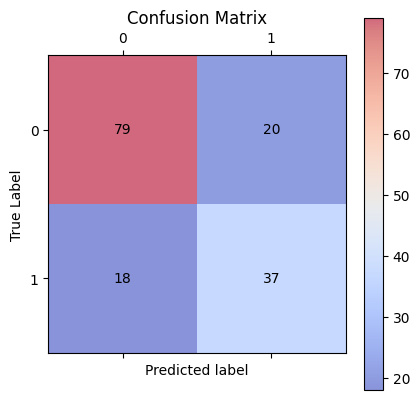

In [104]:
plt.figure(figsize = (14, 6))

#plot confusion matrix
plt.matshow(conf_matrix, cmap = 'coolwarm', alpha = 0.6)
for i in range(conf_matrix.shape[0]):
  for j in range(conf_matrix.shape[1]):
    plt.text(x = j, y = i, s = conf_matrix[i, j], va = 'center', ha = 'center')

plt.xlabel('Predicted label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.colorbar()
plt.show()